# Insurance Risk Prediction – Data Synthesis & Exploratory Data Analysis (EDA)

This notebook covers the generation of a synthetic dataset mimicking real-world insurance data and an in-depth exploratory data analysis (EDA). The goal is to understand the structure, quality, and initial insights of the data prior to modeling.


## Problem Statement

An insurance company wants to predict whether a new customer is likely to file a claim within one year of purchasing a policy. Accurately identifying high-risk customers helps price products appropriately and reduce losses.

The target is to build a model that predicts:
- `claim_status`: 1 = Customer filed a claim; 0 = Did not file a claim.

We begin by synthesizing data that resembles real insurance customer profiles.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
import os

## Step 1: Data Synthesis

We generate a dataset of 10,000+ customer records with 40 features, covering:
- Demographics (e.g. age, marital status)
- Financials (e.g. income, savings, credit score)
- Behavioral and health indicators
- Insurance-related information

We also inject:
- ~2% missing values in selected columns
- ~1% duplicated rows
- A binary target variable `claim_status`


In [2]:
image_output = "../outputs/images"

In [3]:
# Initialize Faker and seed
fake = Faker()
np.random.seed(42)

# Number of records
n_samples = 10_000

# Generate features
data = pd.DataFrame({
    # Numerical features
    'age': np.random.randint(18, 80, size=n_samples),
    'annual_income': np.round(np.random.normal(60000, 15000, size=n_samples), 2),
    'credit_score': np.clip(np.random.normal(680, 50, size=n_samples), 300, 850).astype(int),
    'number_of_dependents': np.random.poisson(1.5, size=n_samples),
    'years_employed': np.random.randint(0, 40, size=n_samples),
    'vehicle_value': np.round(np.random.normal(20000, 10000, size=n_samples), 2),
    'annual_premium': np.round(np.random.normal(1200, 300, size=n_samples), 2),
    'monthly_expenses': np.round(np.random.normal(2500, 800, size=n_samples), 2),
    'savings_amount': np.round(np.random.normal(15000, 10000, size=n_samples), 2),
    'loan_amount': np.round(np.random.normal(10000, 5000, size=n_samples), 2),
    'number_of_policies': np.random.randint(1, 5, size=n_samples),
    'vehicle_ownership_duration': np.random.randint(0, 20, size=n_samples),
    'customer_since_years' : np.random.randint(0, 15, size=n_samples),
    'policy_renewal_count' : np.random.randint(0, 5, size=n_samples),
    
    # Categorical features
    'gender': np.random.choice(['Male', 'Female', 'Other'], size=n_samples, p=[0.48, 0.48, 0.04]),
    'marital_status': np.random.choice(['Single', 'Married', 'Divorced', 'Widowed'], size=n_samples),
    'education_level': np.random.choice(['None', 'High School', 'Bachelor', 'Master', 'PhD'], size=n_samples),
    'job_title': [fake.job() for _ in range(n_samples)],
    'region': np.random.choice(['North', 'South', 'East', 'West', 'Central'], size=n_samples),
    'policy_type': np.random.choice(['Comprehensive', 'Third Party', 'Collision', 'Personal Injury'], size=n_samples),
    'employment_type': np.random.choice(['Salaried', 'Self-Employed', 'Unemployed', 'Retired', 'Student'], size=n_samples),
    'payment_frequency': np.random.choice(['Monthly', 'Quarterly', 'Yearly'], size=n_samples),
    'communication_preference': np.random.choice(['Email', 'Phone', 'SMS', 'In-person'], size=n_samples),
    'relationship_to_policyholder': np.random.choice(['Self', 'Spouse', 'Child', 'Parent', 'Other'], size=n_samples),
    
    # Ordinal features
    'health_status': np.random.choice(['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'], size=n_samples, p=[0.1, 0.2, 0.4, 0.2, 0.1]),
    'driving_record': np.random.choice(['Very Bad', 'Bad', 'Average', 'Good', 'Excellent'], size=n_samples),
    'home_ownership': np.random.choice(['Renter', 'Owner', 'Mortgage', 'Living with Family'], size=n_samples),
    'risk_appetite': np.random.choice(['Low', 'Medium', 'High'], size=n_samples, p=[0.4, 0.4, 0.2]),
    'credit_utilization_band': np.random.choice(['Low', 'Medium', 'High', 'Very High'], size=n_samples),
    
    # Boolean features
    'owns_vehicle': np.random.choice([0, 1], size=n_samples, p=[0.3, 0.7]),
    'has_children': np.random.choice([0, 1], size=n_samples, p=[0.5, 0.5]),
    'has_previous_claims': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
    'is_smoker': np.random.choice([0, 1], size=n_samples, p=[0.75, 0.25]),
    'is_diabetic': np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2]),
    'owns_multiple_policies': np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4]),
    'has_health_insurance': np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3]),
    'is_student': np.random.choice([0, 1], size=n_samples, p=[0.1, 0.9]),
    'has_loyalty_discount': np.random.choice([0, 1], size=n_samples, p=[0.4, 0.6]),
    'attended_defensive_driving': np.random.choice([
        0, 1], size=n_samples, p=[0.3, 0.7])
})


In [4]:
# Randomly inject missing values
cols_with_missing = ['credit_score', 'education_level', 'job_title', 'health_status']
for col in cols_with_missing:
    data.loc[data.sample(frac=0.02).index, col] = np.nan

In [5]:
# Duplicate 1% of rows
duplicates = data.sample(frac=0.01, random_state=42)
data = pd.concat([data, duplicates], ignore_index=True).reset_index(drop=True)

In [6]:
# Fill nulls for scoring logic
data['credit_score_fill'] = data['credit_score'].fillna(680)
data['health_status_fill'] = data['health_status'].fillna('Good')
data['driving_record_fill'] = data['driving_record'].fillna('Average')

# Risk score calculation
risk_score = (
    (data['age'] < 25).astype(int) +
    (data['credit_score_fill'] < 600).astype(int) +
    (data['has_previous_claims']) +
    (data['health_status_fill'].map({'Poor': 1, 'Fair': 1, 'Good': 0, 'Very Good': 0, 'Excellent': 0})) +
    (data['driving_record_fill'].map({'Very Bad': 1, 'Bad': 1, 'Average': 0, 'Good': 0, 'Excellent': 0}))
)

# Convert risk score into probability
probability = 0.05 + 0.15 * (risk_score / risk_score.max())
probability = np.clip(probability, 0, 1)

# Create binary label using probability
data['claim_status'] = np.random.binomial(1, probability)

# Drop temp scoring columns
data.drop(columns=['credit_score_fill', 'health_status_fill', 'driving_record_fill'], inplace=True)

In [7]:
data.columns

Index(['age', 'annual_income', 'credit_score', 'number_of_dependents',
       'years_employed', 'vehicle_value', 'annual_premium', 'monthly_expenses',
       'savings_amount', 'loan_amount', 'number_of_policies',
       'vehicle_ownership_duration', 'customer_since_years',
       'policy_renewal_count', 'gender', 'marital_status', 'education_level',
       'job_title', 'region', 'policy_type', 'employment_type',
       'payment_frequency', 'communication_preference',
       'relationship_to_policyholder', 'health_status', 'driving_record',
       'home_ownership', 'risk_appetite', 'credit_utilization_band',
       'owns_vehicle', 'has_children', 'has_previous_claims', 'is_smoker',
       'is_diabetic', 'owns_multiple_policies', 'has_health_insurance',
       'is_student', 'has_loyalty_discount', 'attended_defensive_driving',
       'claim_status'],
      dtype='object')

In [8]:
data.shape

(10100, 40)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           10100 non-null  int32  
 1   annual_income                 10100 non-null  float64
 2   credit_score                  9898 non-null   float64
 3   number_of_dependents          10100 non-null  int32  
 4   years_employed                10100 non-null  int32  
 5   vehicle_value                 10100 non-null  float64
 6   annual_premium                10100 non-null  float64
 7   monthly_expenses              10100 non-null  float64
 8   savings_amount                10100 non-null  float64
 9   loan_amount                   10100 non-null  float64
 10  number_of_policies            10100 non-null  int32  
 11  vehicle_ownership_duration    10100 non-null  int32  
 12  customer_since_years          10100 non-null  int32  
 13  p

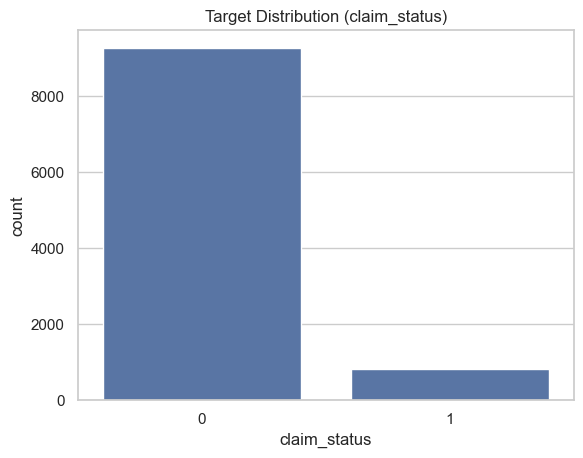

claim_status
0    0.91802
1    0.08198
Name: proportion, dtype: float64

In [10]:
sns.countplot(x='claim_status', data=data)
plt.title("Target Distribution (claim_status)")
plt.savefig(f"{image_output}/target_distribution.png")
plt.show()

data['claim_status'].value_counts(normalize=True)

In [11]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical features:\n", numerical_cols)

data[numerical_cols].describe()

Numerical features:
 ['annual_income', 'credit_score', 'vehicle_value', 'annual_premium', 'monthly_expenses', 'savings_amount', 'loan_amount', 'owns_vehicle', 'has_children', 'has_previous_claims', 'is_smoker', 'is_diabetic', 'owns_multiple_policies', 'has_health_insurance', 'is_student', 'has_loyalty_discount', 'attended_defensive_driving']


,annual_income,credit_score,vehicle_value,annual_premium,monthly_expenses,savings_amount,loan_amount,owns_vehicle,has_children,has_previous_claims,is_smoker,is_diabetic,owns_multiple_policies,has_health_insurance,is_student,has_loyalty_discount,attended_defensive_driving
count,10100.000000,9898.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000
mean,59904.554428,679.784603,20011.446479,1203.181650,2499.187367,15031.091418,9970.249684,0.702772,0.493663,0.149901,0.252277,0.199109,0.404059,0.304059,0.895545,0.592079,0.700792
std,15018.743595,48.983752,10098.960279,297.767343,805.695175,10018.258512,4986.855834,0.457060,0.499985,0.356992,0.434341,0.399350,0.490733,0.460031,0.305866,0.491473,0.457934
min,-810.750000,505.000000,-21577.340000,82.160000,-1070.370000,-19269.830000,-8525.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49551.295000,646.000000,13213.237500,998.787500,1959.167500,8424.245000,6608.062500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,59984.425000,680.000000,20076.255000,1206.025000,2496.130000,14916.110000,9985.700000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,70033.677500,713.000000,26901.385000,1404.270000,3042.320000,21647.817500,13333.235000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,113992.000000,850.000000,57453.790000,2260.810000,5508.120000,53297.820000,28830.900000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Step 2: Data Quality – Missing Values & Duplicates

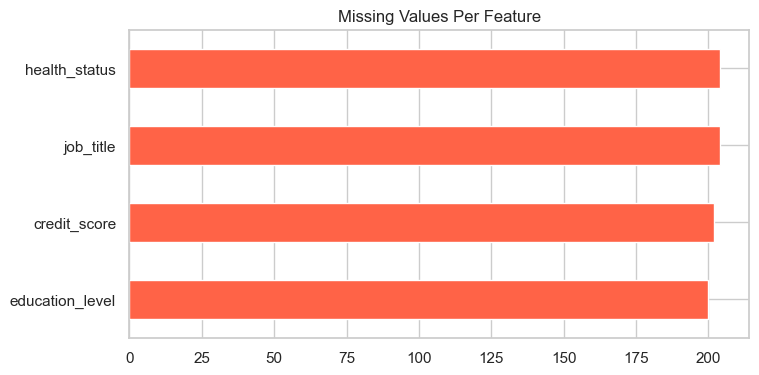

Duplicate rows: 84


In [12]:
missing = data.isnull().sum()
missing[missing > 0].sort_values().plot(kind='barh', figsize=(8, 4), color='tomato')
plt.title('Missing Values Per Feature')
plt.savefig(f"{image_output}/missing_values.png")
plt.show()
print("Duplicate rows:", data.duplicated().sum())


## Step 3: Exploratory Data Analysis (EDA)

We now visualize the distribution of key features and relationships with `claim_status`.


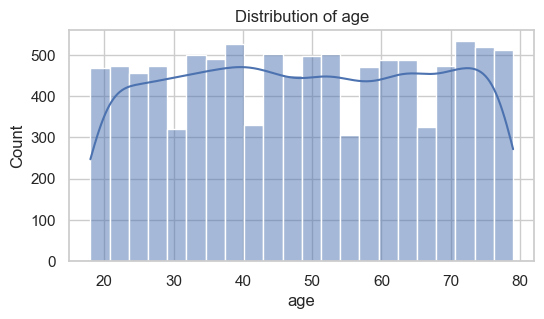

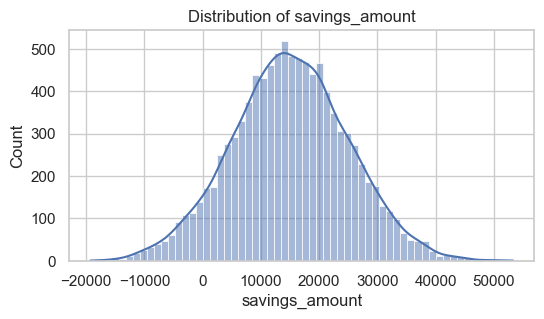

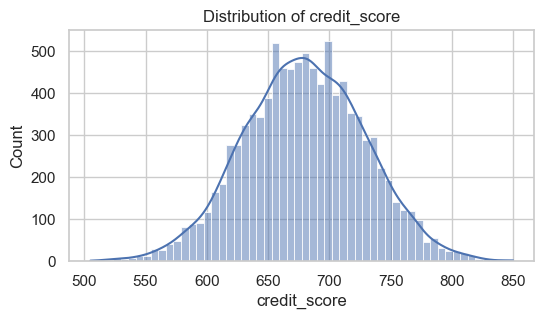

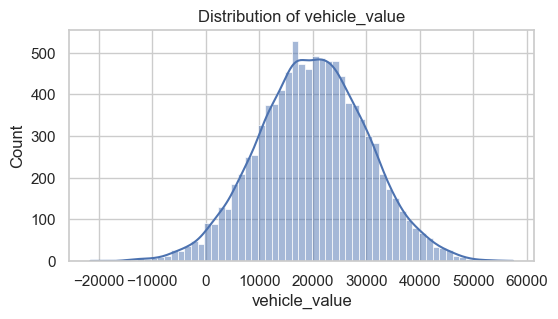

In [13]:
# Plot a few numerical features
sample_num_cols = ['age', 'savings_amount', 'credit_score', 'vehicle_value']

for col in sample_num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.savefig(f"{image_output}/Distribution_of_{col}.png")
    plt.show()

In [14]:
# Categorical features
categorical_cols = data.select_dtypes(include='object').columns.tolist()
print("🔡 Categorical/Ordinal features:\n", categorical_cols)

# View value counts
for col in categorical_cols:
    print(f"\n📊 {col} distribution:")
    print(data[col].value_counts(dropna=False))


🔡 Categorical/Ordinal features:
 ['gender', 'marital_status', 'education_level', 'job_title', 'region', 'policy_type', 'employment_type', 'payment_frequency', 'communication_preference', 'relationship_to_policyholder', 'health_status', 'driving_record', 'home_ownership', 'risk_appetite', 'credit_utilization_band']

📊 gender distribution:
gender
Male      4869
Female    4819
Other      412
Name: count, dtype: int64

📊 marital_status distribution:
marital_status
Divorced    2600
Married     2554
Single      2554
Widowed     2392
Name: count, dtype: int64

📊 education_level distribution:
education_level
Master         2014
High School    2004
Bachelor       1977
PhD            1974
None           1931
NaN             200
Name: count, dtype: int64

📊 job_title distribution:
job_title
NaN                         204
Museum education officer     28
Insurance claims handler     28
Occupational hygienist       27
Medical secretary            27
                           ... 
Manufacturing eng

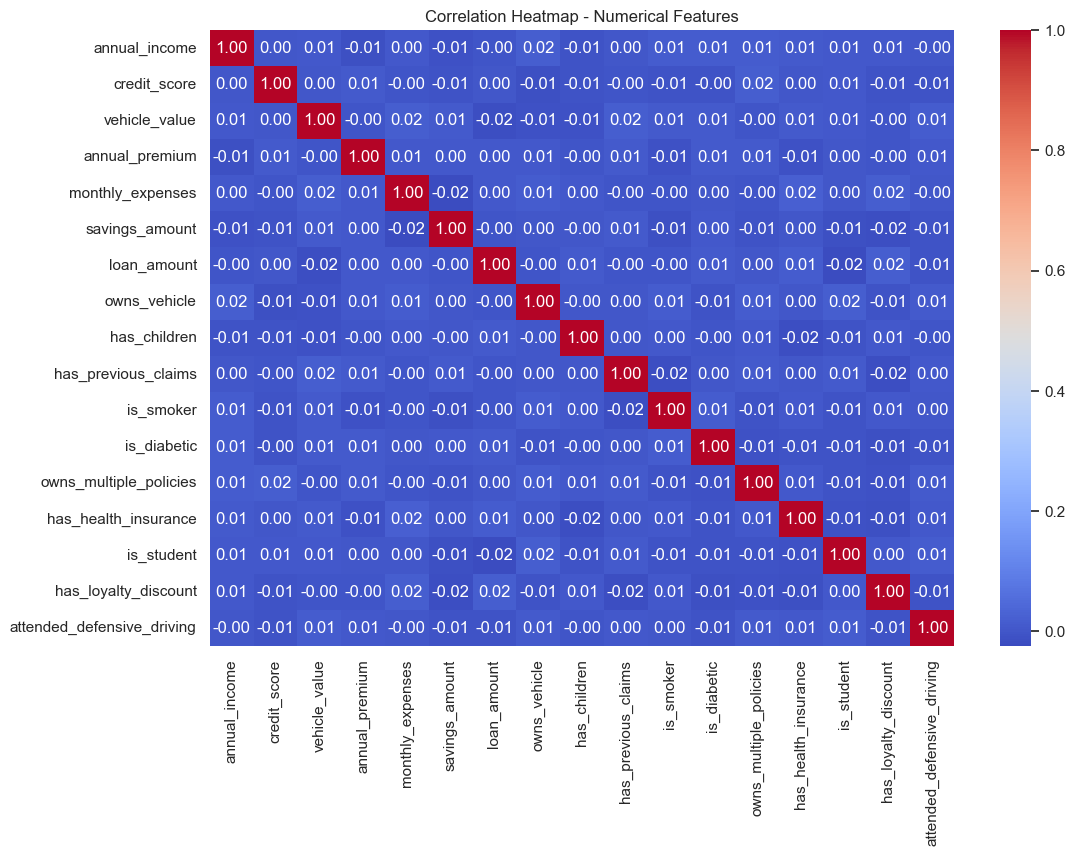

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(data[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Numerical Features')
plt.savefig(f"{image_output}/correlation.png", bbox_inches="tight")
plt.show()

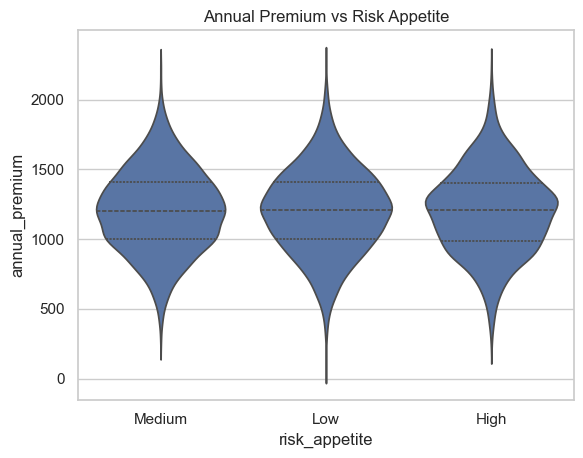

In [16]:
sns.violinplot(x='risk_appetite', y='annual_premium', data=data, inner='quartile')
plt.title('Annual Premium vs Risk Appetite')
plt.savefig(f"{image_output}/annual_premium_vs_risk_appetite.png")
plt.show()

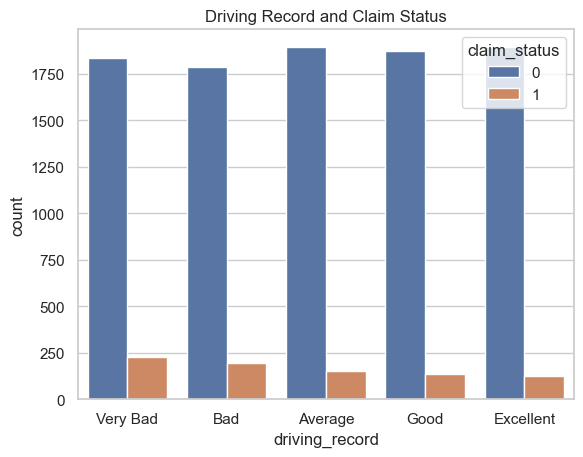

In [17]:
sns.countplot(x='driving_record', hue='claim_status', data=data, order=['Very Bad', 'Bad', 'Average', 'Good', 'Excellent'])
plt.title('Driving Record and Claim Status')
plt.savefig(f"{image_output}/driving_record_vs_claims.png")
plt.show()

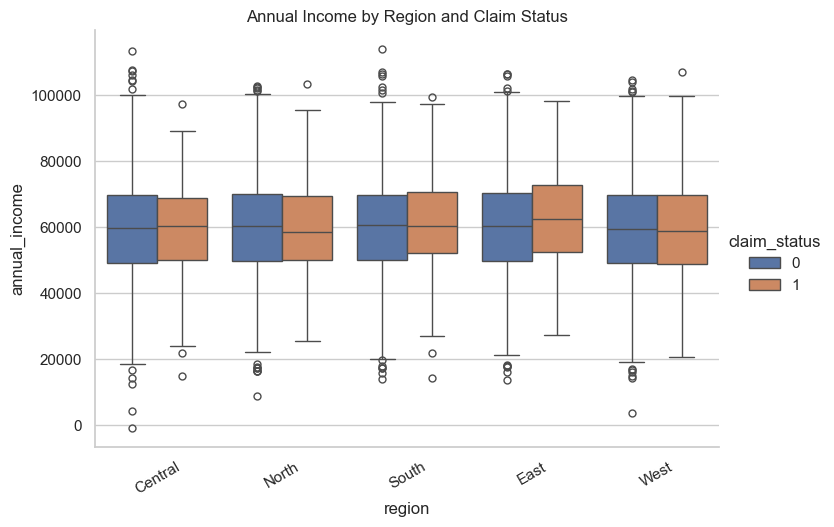

In [18]:
sns.catplot(
    data=data, x='region', y='annual_income',
    hue='claim_status', kind='box',
    height=5, aspect=1.5
)
plt.title('Annual Income by Region and Claim Status')
plt.xticks(rotation=30)
plt.savefig(f"{image_output}/annual_income_vs_claims.png")
plt.show()

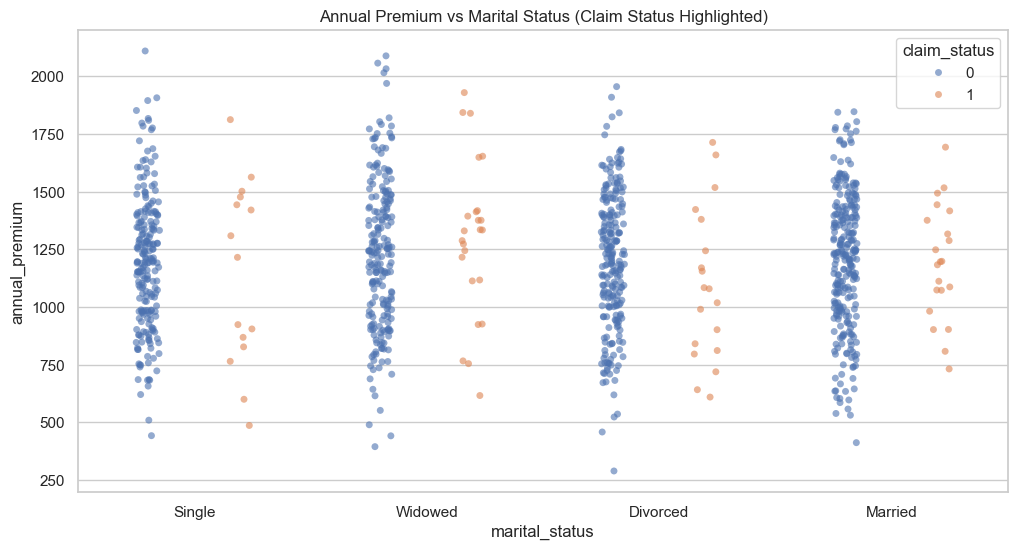

In [19]:
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=data.sample(1000), x='marital_status', y='annual_premium',
    hue='claim_status', jitter=True, dodge=True, alpha=0.6
)
plt.title('Annual Premium vs Marital Status (Claim Status Highlighted)')
plt.savefig(f"{image_output}/annual_premium_vs_marital.png")
plt.show()

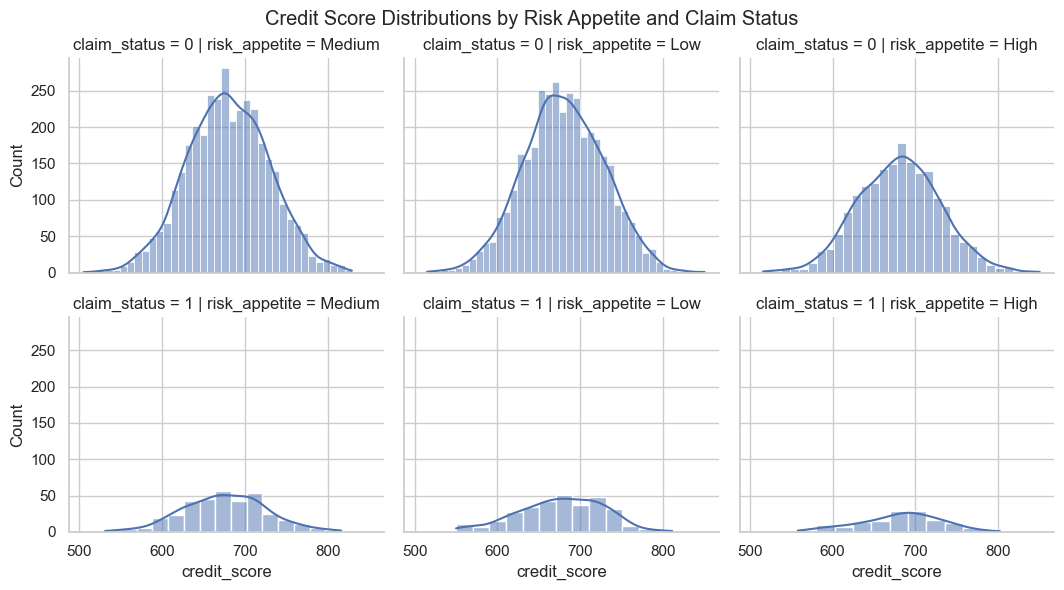

In [20]:
g = sns.FacetGrid(data, col='risk_appetite', row='claim_status', height=3, aspect=1.2)
g.map(sns.histplot, 'credit_score', kde=True)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Credit Score Distributions by Risk Appetite and Claim Status')
plt.savefig(f"{image_output}/distributions_riskappetite_claimstatus.png")
plt.show()

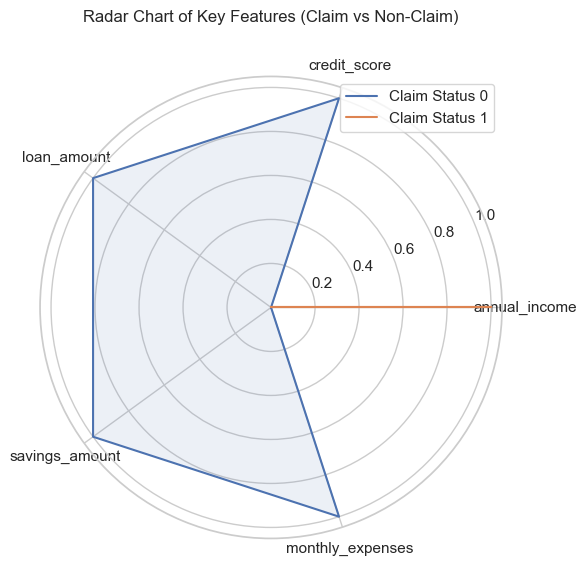

In [21]:
features = ['annual_income', 'credit_score', 'loan_amount', 'savings_amount', 'monthly_expenses']
grouped = data.groupby('claim_status')[features].mean()

# Normalize for radar
grouped_norm = grouped.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

import matplotlib.pyplot as plt
import numpy as np

labels=np.array(features)
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for i, row in grouped_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Claim Status {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_title('Radar Chart of Key Features (Claim vs Non-Claim)', y=1.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.legend()
plt.savefig(f"{image_output}/radar_claims_vs_nonclaims.png")
plt.show()

In [22]:
save_dir = '../data'
os.makedirs(save_dir, exist_ok=True)
file_path = os.path.join(save_dir, 'insurance_preprocessed.csv')
data.to_csv(file_path, index=False)

##  EDA Summary

- The dataset covers diverse customer attributes, reasonably distributed.
- Class imbalance is visible (~7–8% claimants).
- Some features like `age`, `credit_score`, `previous_claims` show separation.
- We'll handle missing values and encoding in the next notebook.

 Next: `Data Preprocessing & Modeling.ipynb`
